### Model Training
Purpose: Make a baseline model on full_features.csv

### Import Libraries

In [26]:
import json
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from pathlib import Path 
from datetime import datetime, timezone
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

### Set up directory paths

In [27]:
PROCCESED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
DOCS_DIR = Path("../docs")
MODELS_DIR.mkdir(exist_ok=True)
DOCS_DIR.mkdir(exist_ok=True)
(DOCS_DIR / "screenshots").mkdir(exist_ok=True)

LABEL_NAMES = {1: "low", 2: "medium", 3: "high"}


### Load in the features and split off accordingly

In [28]:
full_features = pd.read_csv(PROCCESED_DIR / "full_features.csv")

non_feature_cols = ["subject", "test", "phase"]
feature_cols = [c for c in full_features.columns if c not in non_feature_cols]

X = full_features[feature_cols]
y = full_features["test"]
groups = full_features["subject"]

print(f"Samples: {len(X)}, Features: {len(feature_cols)}, Subjects: {groups.nunique()}\n")
print(f"Feature-to-sample ratio: {len(feature_cols)/len(X):.3f}")
print("REMINDER: Keep track of this ratio!")

print(f"Infs in ratio: {np.isinf(full_features["frontal_theta_beta_ratio"]).sum()}")
print(f"Nulls in ratio:", full_features["frontal_theta_beta_ratio"].isna().sum())
print(f"Ratio Max: {full_features["frontal_theta_beta_ratio"].max()}")
print("Ratio Min:", full_features["frontal_theta_beta_ratio"].min())

variances = X.var()
print("\nLowest feature variances:\n", variances.sort_values().head(10))

Samples: 18505, Features: 71, Subjects: 16

Feature-to-sample ratio: 0.004
REMINDER: Keep track of this ratio!
Infs in ratio: 0
Nulls in ratio: 0
Ratio Max: 0.0241660116715853
Ratio Min: 4.993054115517283e-05

Lowest feature variances:
 frontal_theta_beta_ratio    0.000003
EEG.F8_beta                 4.525131
EEG.O1_beta                 5.165553
EEG.F4_beta                 5.479628
EEG.F3_beta                 5.594347
EEG.F7_beta                 5.936616
EEG.FC5_beta                6.132864
EEG.AF4_beta                6.135137
EEG.FC6_beta                6.164284
EEG.AF3_beta                6.509861
dtype: float64


### Cross-validation amongst subject groups

In [29]:
n_splits = min(5, groups.nunique())
cv = GroupKFold(n_splits=n_splits)
clf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)

y_pred = cross_val_predict(clf, X, y, groups=groups, cv=cv)
accuracy = accuracy_score(y, y_pred)
macro_f1 = f1_score(y, y_pred, average="macro")

print(f"Cross-validated accuracy: {accuracy:.3f}\n")
print(f"Cross-validated macro F1: {macro_f1:.3f}\n")
print(f"\n{classification_report(y, y_pred, target_names=[LABEL_NAMES[c] for c in sorted(y.unique())])}")

Cross-validated accuracy: 0.402

Cross-validated macro F1: 0.399


              precision    recall  f1-score   support

         low       0.49      0.43      0.46      6331
      medium       0.37      0.29      0.32      6083
        high       0.36      0.48      0.41      6091

    accuracy                           0.40     18505
   macro avg       0.41      0.40      0.40     18505
weighted avg       0.41      0.40      0.40     18505



### Making the confusion matrix

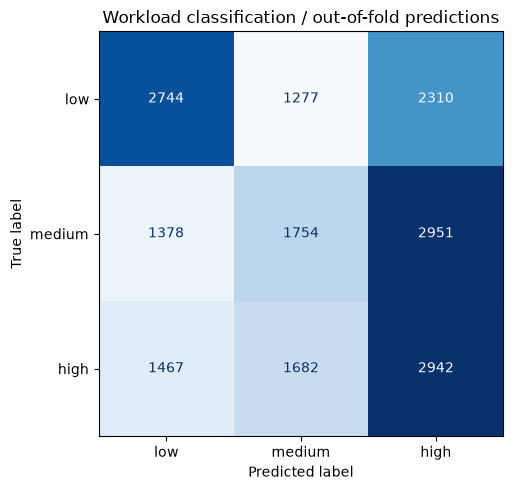

In [30]:
labels_sorted = sorted(y.unique())
cm = confusion_matrix(y, y_pred, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[LABEL_NAMES[c] for c in labels_sorted])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Workload classification / out-of-fold predictions")
plt.tight_layout()
plt.savefig(DOCS_DIR / "screenshots" / "confusion_matrix.png", dpi=150)
plt.show()

### Fitting the final model on full_features.csv

Top 15 features:
EEG.AF4_beta     0.023107
EEG.O2_beta      0.022125
EEG.F7_delta     0.021184
EEG.F3_alpha     0.021126
EEG.P7_beta      0.020957
EEG.F7_theta     0.020289
EEG.T7_beta      0.019778
EEG.FC5_gamma    0.019492
EEG.AF4_gamma    0.019465
EEG.P8_beta      0.018291
EEG.P8_delta     0.018065
EEG.P7_delta     0.017939
EEG.O2_gamma     0.017821
EEG.FC6_beta     0.017585
EEG.FC6_alpha    0.017505
dtype: float64


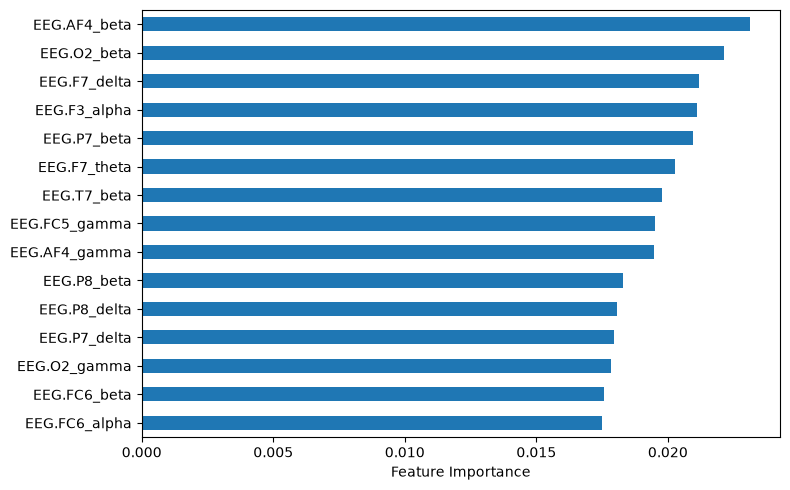

In [31]:
final_model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
final_model.fit(X,y)

importances = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(f"Top 15 features:\n{importances.head(15)}")

fig, ax = plt.subplots(figsize=(8,5))
sorted_importances = importances.head(15).sort_values()
sorted_importances.plot(kind="barh", ax=ax)
ax.set_xlabel("Feature Importance")
plt.tight_layout()
plt.savefig(DOCS_DIR / "screenshots" / "feature_importance.png", dpi=150)
plt.show()

### Saving the model and summarizing

In [33]:
model_path = MODELS_DIR / "baseline_random_forest.joblib"
joblib.dump(final_model, model_path)
print(f"Saved the model to {model_path}")

report_dict = classification_report(y, y_pred, target_names=[LABEL_NAMES[c] for c in labels_sorted],
                                    output_dict=True)

metrics = {
     "generated_at": datetime.now(timezone.utc).isoformat(),
     "n_samples": len(X),
     "n_features": len(feature_cols),
     "n_subjects": int(groups.nunique()),
     "cv_folds": n_splits,
     "cv_accuracy": accuracy,
     "cv_macro_f1": macro_f1,
     "per_class_report": report_dict,
     "top_10_features": importances.head(10).to_dict()
}

with open(DOCS_DIR / "metrics.json", "w") as f:
     json.dump(metrics, f, indent=2)
print(f"Finalized metrics saved to {DOCS_DIR / 'metrics.json'}")

Saved the model to ..\models\baseline_random_forest.joblib
Finalized metrics saved to ..\docs\metrics.json


### Findings and Results
cv_accuracy is 40.21%
macro_f1 is 39.90%
this is across

This compares to the baseline because it is about 7% more than the random quessing baseline which suggests that the model is actually learning and finding patterns. 

The medium class is struggling the most. I think the extremes of the low and high class represent the distinct shifts in the brain's signaling especially compared to restful vs. stresful piloting activites. The medium class is more of a gray area that is harder to classify. Low and high represent the physiological distinct states.

The beta band power is the dominant pattern. Especially across several scalp regions such as AF4, O2, P7, and T7. The data signifies a distributed signature rather than one singular marker. There is no single importance that dominates. However, the AF4_gamma could be affecting the data due to it's reflection eye-movement artifacts even though a significant portion of it was filtered out in the preprocessing. 

There was some overfitting in my first runs of the model which led me to conclude that I need to change the band_power calculations. Before the cv accuracy was 35.9%. The ratio was at importance 1 and all 70 others were at 0.0. It signified a model that was unregularized. The model was memorizing an unstable and high-variance feature rather than something that is generalizable. After converting band power to the dB scale and climping the ratio feature by adding epsilon in the denominator, the accuracy rose to 40.2% and importances spread across more sensibly. 